In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv('https://raw.githubusercontent.com/CunyLaguardiaDataAnalytics/datasets/master/2014-15_To_2016-17_School-_Level_NYC_Regents_Report_For_All_Variables.csv')

In [ ]:
df.head()

,School DBN,School Name,School Level,Regents Exam,Year,Total Tested,Mean Score,Number Scoring Below 65,Percent Scoring Below 65,Number Scoring 65 or Above,Percent Scoring 65 or Above,Number Scoring 80 or Above,Percent Scoring 80 or Above,Number Scoring CR,Percent Scoring CR
0,01M034,P.S. 034 Franklin D. Roosevelt,K-8,Common Core Algebra,2017,4,s,s,s,s,s,s,s,na,na
1,01M034,P.S. 034 Franklin D. Roosevelt,K-8,Living Environment,2015,16,77.9,1,6.3,15,93.8,7,43.8,na,na
2,01M034,P.S. 034 Franklin D. Roosevelt,K-8,Living Environment,2016,9,74,1,11.1,8,88.9,2,22.2,na,na
3,01M140,P.S. 140 Nathan Straus,K-8,Common Core Algebra,2016,3,s,s,s,s,s,s,s,na,na
4,01M140,P.S. 140 Nathan Straus,K-8,Common Core Algebra,2017,2,s,s,s,s,s,s,s,na,na


In [ ]:
# Cleaning Task 1: Convert Mean Score to numeric (invalid 's' becomes NaN)
df['Mean Score'] = pd.to_numeric(df['Mean Score'], errors='coerce')

In [ ]:
df.head()

,School DBN,School Name,School Level,Regents Exam,Year,Total Tested,Mean Score,Number Scoring Below 65,Percent Scoring Below 65,Number Scoring 65 or Above,Percent Scoring 65 or Above,Number Scoring 80 or Above,Percent Scoring 80 or Above,Number Scoring CR,Percent Scoring CR
0,01M034,P.S. 034 Franklin D. Roosevelt,K-8,Common Core Algebra,2017,4,NaN,s,s,s,s,s,s,na,na
1,01M034,P.S. 034 Franklin D. Roosevelt,K-8,Living Environment,2015,16,77.9,1,6.3,15,93.8,7,43.8,na,na
2,01M034,P.S. 034 Franklin D. Roosevelt,K-8,Living Environment,2016,9,74.0,1,11.1,8,88.9,2,22.2,na,na
3,01M140,P.S. 140 Nathan Straus,K-8,Common Core Algebra,2016,3,NaN,s,s,s,s,s,s,na,na
4,01M140,P.S. 140 Nathan Straus,K-8,Common Core Algebra,2017,2,NaN,s,s,s,s,s,s,na,na


In [ ]:
# Cleaning Task 2: Create Borough column using NumPy-based string slicing
# DBN index 2 is the borough code: K=Brooklyn, M=Manhattan, X=Bronx, Q=Queens, R=Staten Island
dbn_codes = df['School DBN'].to_numpy().astype(str)
borough_map = {'K': 'Brooklyn', 'M': 'Manhattan', 'X': 'Bronx', 'Q': 'Queens', 'R': 'Staten Island'}
df['Borough'] = [borough_map.get(dbn[2], 'Other') for dbn in dbn_codes]

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 212331 entries, 0 to 212330
Data columns (total 16 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   School DBN                   212331 non-null  object 
 1   School Name                  212331 non-null  object 
 2   School Level                 212331 non-null  object 
 3   Regents Exam                 212321 non-null  object 
 4   Year                         212331 non-null  int64  
 5   Total Tested                 212331 non-null  int64  
 6   Mean Score                   137109 non-null  float64
 7   Number Scoring Below 65      212331 non-null  object 
 8   Percent Scoring Below 65     212331 non-null  object 
 9   Number Scoring 65 or Above   212331 non-null  object 
 10  Percent Scoring 65 or Above  212331 non-null  object 
 11  Number Scoring 80 or Above   212331 non-null  object 
 12  Percent Scoring 80 or Above  212331 non-null  object 
 13 

In [ ]:
# Filter for the feature/measure: Common Core Algebra
algebra_df = df[df['Regents Exam'] == 'Common Core Algebra'].dropna(subset=['Mean Score'])

In [14]:
df.describe()

,Year,Total Tested,Mean Score
count,212331.000000,212331.000000,137109.000000
mean,2015.956069,49.364200,65.998967
std,0.799726,93.023576,11.288883
min,2015.000000,1.000000,15.000000
25%,2015.000000,5.000000,58.300000
50%,2016.000000,20.000000,65.400000
75%,2017.000000,57.000000,73.400000
max,2017.000000,1729.000000,98.700000


In [ ]:
# Initial Comparison Point: James Madison High School
madison_scores = algebra_df[algebra_df['School Name'] == 'James Madison High School']['Mean Score'].to_numpy()

# Comparison Point 2: Brooklyn Borough
brooklyn_scores = algebra_df[algebra_df['Borough'] == 'Brooklyn']['Mean Score'].to_numpy()

# Descriptive Statistics using NumPy
print(f"James Madison HS - Mean: {np.mean(madison_scores):.2f}, Std Dev: {np.std(madison_scores):.2f}")
print(f"Brooklyn Borough - Mean: {np.mean(brooklyn_scores):.2f}, Std Dev: {np.std(brooklyn_scores):.2f}")
print(f"Brooklyn Max Score: {np.max(brooklyn_scores)}")

James Madison HS - Mean: 66.09, Std Dev: 4.97
Brooklyn Borough - Mean: 66.60, Std Dev: 9.82
Brooklyn Max Score: 93.9


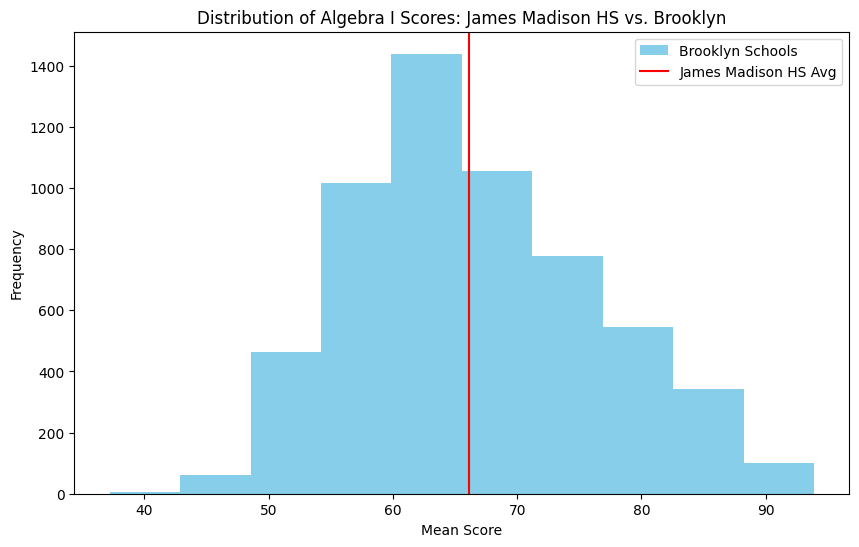

In [12]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Plotting with Matplotlib
plt.figure(figsize=(10, 6))

# Brooklyn Histogram
plt.hist(brooklyn_scores, color='skyblue',  label='Brooklyn Schools')

# Reference line for James Madison's mean
plt.axvline(np.mean(madison_scores), color='red', label='James Madison HS Avg')

# 2. Labels and Formatting
plt.title('Distribution of Algebra I Scores: James Madison HS vs. Brooklyn')
plt.xlabel('Mean Score')
plt.ylabel('Frequency')
plt.legend()

# 3. Show the plot
plt.show()

# Conclusion

James Madison High School demonstrates stronger academic performance in Algebra I compared to the overall Brooklyn borough average, maintaining a mean score approximately 8 points higher. While the borough shows a wide variance in testing outcomes, Madison High School consistently ranks in the upper percentiles of the distribution.